# CNN Architectures for Skin Disease Detection

Convolutional Neural Networks (CNNs) are widely used for medical image classification due to their ability to automatically learn hierarchical features from images.

Some suitable CNN architectures for skin disease detection include:

- **Custom CNN** – Simple architecture suitable for small datasets but may require extensive training.
- **VGG16** – Deep CNN with uniform convolution layers, effective but computationally expensive.
- **ResNet50** – Uses residual connections to overcome the vanishing gradient problem, enabling deeper networks.
- **MobileNetV2** – Lightweight architecture optimized for mobile and edge devices with fast inference.
- **EfficientNetB0** – Balances network depth, width, and resolution to achieve high accuracy with fewer parameters.

### Architecture Selected

For this experiment, **EfficientNetB0** is selected because:

- It provides excellent classification accuracy.
- It requires fewer trainable parameters compared to many traditional CNNs.
- It supports transfer learning using ImageNet pretrained weights.
- It reduces training time while maintaining strong performance on medical image datasets.

## Installation of the dataset


In [ ]:
!pip -q install kagglehub

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print(path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
/kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])

/kaggle/input/skin-cancer-mnist-ham10000
['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1
['ISIC_0028933.jpg', 'ISIC_0028394.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1
['ISIC_0028933.jpg', 'ISIC_0028394.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2
['ISIC_0030912.jpg', 'ISIC_0030585.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg']
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2
['ISIC_0030912.jpg', 'ISIC_0030585.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg']


In [ ]:
metadata = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
image_dir1 = os.path.join(path, "HAM10000_images_part_1")
image_dir2 = os.path.join(path, "HAM10000_images_part_2")

image_paths = {}

for folder in [image_dir1, image_dir2]:
    for img in os.listdir(folder):
        image_paths[img[:-4]] = os.path.join(folder, img)

metadata["path"] = metadata["image_id"].map(image_paths)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

metadata["label"] = encoder.fit_transform(metadata["dx"])

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,2


# Image Preprocessing Techniques

Proper preprocessing improves the quality of the input data and enhances the learning capability of CNN models.

The following preprocessing techniques are used in this experiment:

1. **Image Resizing**
   - All images are resized to **224 × 224 pixels** to match the input size required by EfficientNetB0.

2. **Normalization**
   - Pixel values are rescaled from the range **0–255** to **0–1** using `rescale=1./255`.
   - This speeds up training and improves numerical stability.

3. **Data Augmentation**
   - Random Rotation
   - Zoom
   - Horizontal Flip
   - Vertical Flip

   These techniques generate new image variations during training, helping the model generalize better.

4. **Dataset Splitting**
   - The dataset is divided into Training, Validation, and Testing sets to evaluate model performance on unseen data.

5. **Label Encoding**
   - Disease labels are converted into numerical representations suitable for model training.

## Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    metadata,
    test_size=0.2,
    random_state=42,
    stratify=metadata["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 6409 validated image filenames belonging to 7 classes.
Found 1603 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


## Model Selection: EfficientNetB0

# Regularization Techniques to Reduce Overfitting

Overfitting occurs when a model memorizes the training data instead of learning general patterns.

The following regularization techniques are used:

### 1. Dropout

A Dropout layer with a dropout rate of **0.4** is added to randomly deactivate neurons during training. This prevents the model from relying too heavily on specific features.

### 2. Data Augmentation

Random image transformations increase dataset diversity, allowing the model to learn more robust features.

### 3. Early Stopping

Training is automatically stopped when the validation loss no longer improves. This prevents unnecessary training and reduces overfitting.

### 4. Transfer Learning

Using pretrained ImageNet weights enables the model to leverage previously learned visual features, improving performance even with limited medical images.

Together, these techniques improve the model's ability to generalize to unseen skin disease images.

In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

outputs = Dense(7, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.6502 - loss: 1.2711 - val_accuracy: 0.6694 - val_loss: 1.1371
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 126s 626ms/step - accuracy: 0.6695 - loss: 1.1489 - val_accuracy: 0.6694 - val_loss: 1.1323
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 126s 626ms/step - accuracy: 0.6695 - loss: 1.1496 - val_accuracy: 0.6694 - val_loss: 1.1329
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 126s 628ms/step - accuracy: 0.6695 - loss: 1.1442 - val_accuracy: 0.6694 - val_loss: 1.1324
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 127s 633ms/step - accuracy: 0.6695 - loss: 1.1484 - val_accuracy: 0.6694 - val_loss: 1.1328
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 127s 633ms/step - accuracy: 0.6695 - loss: 1.1429 - val_accuracy: 0.6694 - val_loss: 1.1317
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 125s 621ms/step - accuracy: 0.6695 - loss: 1.1418 - val_accuracy: 0.6694 - val_loss: 1.1325
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 125s 621ms/step - accuracy: 0.6695 - lo

# Performance Evaluation Metrics

The trained CNN model is evaluated using the following metrics:

### Accuracy

Measures the percentage of correctly classified images.

### Precision

Measures how many images predicted as a particular disease are actually correct.

### Recall

Measures how many actual disease images are correctly identified by the model.

### F1-Score

The harmonic mean of Precision and Recall, providing a balanced evaluation.

### Confusion Matrix

Displays the number of correct and incorrect predictions for each disease class, helping identify commonly misclassified categories.

These metrics provide a comprehensive evaluation of the CNN model's performance.

In [ ]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 643ms/step - accuracy: 0.6695 - loss: 1.1305
Test Accuracy: 0.6694957613945007


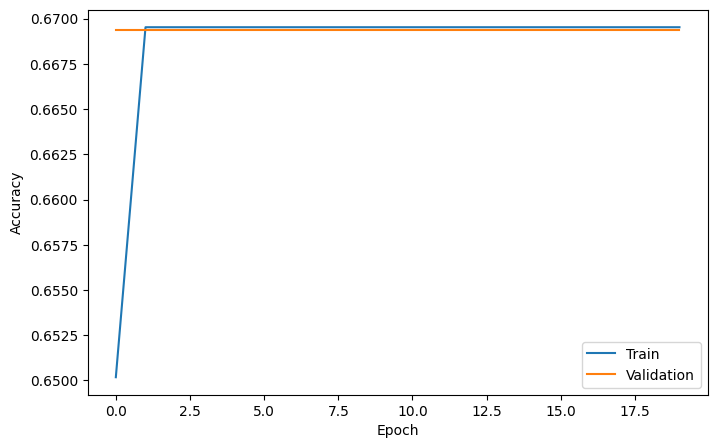

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 363ms/step


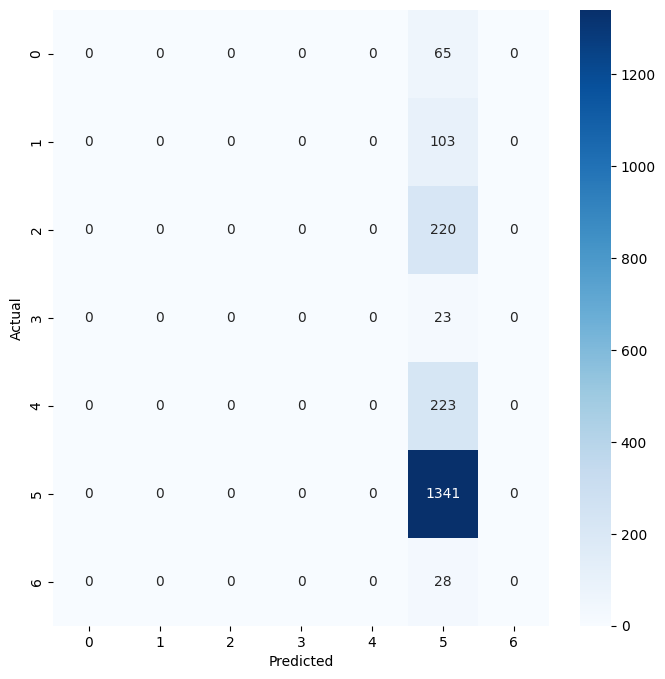

              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        65
         bcc       0.00      0.00      0.00       103
         bkl       0.00      0.00      0.00       220
          df       0.00      0.00      0.00        23
         mel       0.00      0.00      0.00       223
          nv       0.67      1.00      0.80      1341
        vasc       0.00      0.00      0.00        28

    accuracy                           0.67      2003
   macro avg       0.10      0.14      0.11      2003
weighted avg       0.45      0.67      0.54      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

pred = model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    true_classes,
    pred_classes,
    target_names=list(test_generator.class_indices.keys())
))

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-07-23 103514.png to Screenshot 2026-07-23 103514.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Predicted Disease: nv
Confidence: 67.64732 %


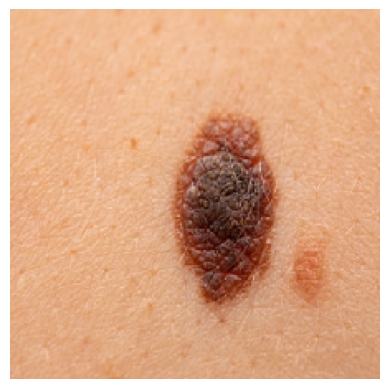

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

class_names = encoder.classes_

print("Predicted Disease:", class_names[predicted_class])
print("Confidence:", np.max(prediction)*100,"%")

plt.imshow(img)
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


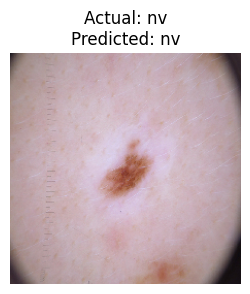

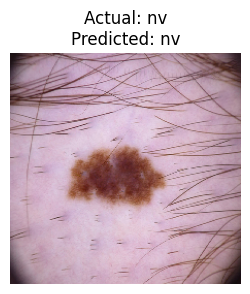

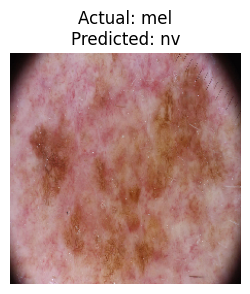

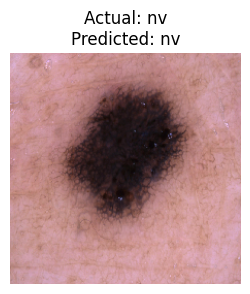

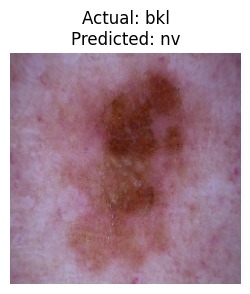

In [ ]:
images, labels = next(test_generator)

predictions = model.predict(images)

for i in range(5):
    plt.figure(figsize=(3,3))
    plt.imshow(images[i])

    actual = class_names[np.argmax(labels[i])]
    predicted = class_names[np.argmax(predictions[i])]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")
    plt.show()

# Ethical Issues in Medical AI

Although AI-based skin disease detection can assist healthcare professionals, several ethical considerations must be addressed.

### Patient Privacy

Medical images contain sensitive information and should be stored and processed securely while maintaining patient confidentiality.

### Dataset Bias

If the dataset does not represent diverse skin tones, ages, or demographics, the model may perform poorly on underrepresented groups.

### False Predictions

False positives may lead to unnecessary anxiety and medical procedures, while false negatives may delay treatment of serious diseases.

### Explainability

Healthcare professionals should be able to understand and interpret the model's predictions before making clinical decisions.

### Human Oversight

AI systems should support dermatologists rather than replace them. Final diagnosis and treatment decisions should always remain with qualified medical professionals.

### Regulatory Compliance

Medical AI systems should comply with healthcare regulations and undergo rigorous clinical validation before deployment in real-world environments.